In [1]:
# 기본세팅 - 한글폰트 설정
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib import font_manager
import matplotlib

In [2]:
# 이 명령어는 코랩 환경에서 나눔고딕 폰트를 설치
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf # matplotlib 캐시 삭제

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 3 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 0s (44.4 MB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 118243 files and direct

In [2]:
# 폰트 경로 설정 (나눔고딕)
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font = font_manager.FontProperties(fname=font_path).get_name()
matplotlib.rc('font', family=font)

# 마이너스 부호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

print("✅ 한글 폰트 설정 완료. 이제 matplotlib 그래프에서 한글을 사용할 수 있습니다.")

✅ 한글 폰트 설정 완료. 이제 matplotlib 그래프에서 한글을 사용할 수 있습니다.


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 데이터 불러오기 → 결측치 확인


In [4]:
# 독립변수(X) 데이터 불러오기
data = pd.read_csv('/content/drive/MyDrive/문화체육관광대회/data/df_merged.csv')
data

,시도명,4성급_이상_호텔,국가유산_현황,국립공원_현황,대중교통_만족도_평균,미세먼지_연평균_농도,전체_면적(km²),박물관_미술관_총계,녹지환경_만족도,총_관광지_수,지역_축제_현황
0,서울특별시,73,2137,1,4.692857,17.416667,605.214148,339,55.6,60.0,163
1,부산광역시,16,570,0,4.667143,13.916667,771.333243,80,57.7,74.0,54
2,대구광역시,7,336,1,4.660952,14.166667,1499.491740,60,48.7,14.0,68
3,인천광역시,11,287,0,4.680476,18.750000,1069.512043,67,47.8,13.0,48
4,광주광역시,3,165,1,4.643810,13.833333,500.952986,50,50.4,15.0,29
5,대전광역시,3,235,1,4.658095,14.416667,539.756107,44,53.5,15.0,16
6,울산광역시,4,166,0,4.617778,14.750000,1062.903939,25,57.3,7.0,29
7,세종특별자치시,1,64,0,4.602222,16.416667,465.008547,13,76.3,NaN,5
8,경기도,17,1305,1,4.664286,17.354167,10201.223543,346,59.5,60.0,211
9,충청북도,1,860,3,4.640556,16.326389,7406.941438,108,59.3,29.0,38


In [9]:
print(data.isnull())
print(data.isnull().sum())

      시도명  4성급_이상_호텔  국가유산_현황   국립공원_현황  대중교통_만족도_평균  미세먼지_연평균_농도  전체_면적(km²)  \
0   False      False     False    False        False        False       False   
1   False      False     False    False        False        False       False   
2   False      False     False    False        False        False       False   
3   False      False     False    False        False        False       False   
4   False      False     False    False        False        False       False   
5   False      False     False    False        False        False       False   
6   False      False     False    False        False        False       False   
7   False      False     False    False        False        False       False   
8   False      False     False    False        False        False       False   
9   False      False     False    False        False        False       False   
10  False      False     False    False        False        False       False   
11  False      False     Fal

In [10]:
data.fillna(0, inplace=True)

In [11]:
print(data.isnull().sum()) # 기존 데이터프레임 결측치 X

시도명            0
4성급_이상_호텔      0
국가유산_현황        0
국립공원_현황        0
대중교통_만족도_평균    0
미세먼지_연평균_농도    0
전체_면적(km²)     0
박물관_미술관_총계     0
녹지환경_만족도       0
총_관광지_수        0
지역_축제_현황       0
dtype: int64


In [12]:
# 종속변수(Y) 데이터 불러오기
data_y = pd.read_csv('/content/drive/MyDrive/문화체육관광대회/data/rawdata/2024_월간방문자수(이동통신데이터 기반 유형별 전국 방문자 수).csv')
data_y.head()

,시도명,방문자수
0,서울특별시,595780850.0
1,부산광역시,150240038.0
2,대구광역시,105352492.0
3,인천광역시,177319548.0
4,광주광역시,66355821.0


In [16]:
# X, Y 데이터 합치기
combined_data = pd.merge(data, data_y, on='시도명', how='inner')
combined_data.head()

,시도명,4성급_이상_호텔,국가유산_현황,국립공원_현황,대중교통_만족도_평균,미세먼지_연평균_농도,전체_면적(km²),박물관_미술관_총계,녹지환경_만족도,총_관광지_수,지역_축제_현황,방문자수
0,서울특별시,73,2137,1,4.692857,17.416667,605.214148,339,55.6,60.0,163,595780850.0
1,부산광역시,16,570,0,4.667143,13.916667,771.333243,80,57.7,74.0,54,150240038.0
2,대구광역시,7,336,1,4.660952,14.166667,1499.491740,60,48.7,14.0,68,105352492.0
3,인천광역시,11,287,0,4.680476,18.750000,1069.512043,67,47.8,13.0,48,177319548.0
4,광주광역시,3,165,1,4.643810,13.833333,500.952986,50,50.4,15.0,29,66355821.0


In [17]:
print("독립변수 행 수:", data.shape[0])
print("종속변수 행 수:", data_y.shape[0])
print("합쳐진 데이터 행 수:", combined_data.shape[0])

독립변수 행 수: 17
종속변수 행 수: 17
합쳐진 데이터 행 수: 17


In [18]:
combined_data.isnull().sum()

,0
시도명,0
4성급_이상_호텔,0
국가유산_현황,0
국립공원_현황,0
대중교통_만족도_평균,0
미세먼지_연평균_농도,0
전체_면적(km²),0
박물관_미술관_총계,0
녹지환경_만족도,0
총_관광지_수,0


# 면적별로 나누기
(4성급_이상_호텔, 국가유산_현황, 박물관_미술관_총계, 총_관광지_수, 방문자수)

In [20]:
print(combined_data.columns.tolist()) # 띄어쓰기 되어있는 컬럼 발견

['시도명', '4성급_이상_호텔', '국가유산_현황 ', '국립공원_현황', '대중교통_만족도_평균', '미세먼지_연평균_농도', '전체_면적(km²)', '박물관_미술관_총계', '녹지환경_만족도', '총_관광지_수', '지역_축제_현황', '방문자수']


In [22]:
combined_data.columns = combined_data.columns.str.replace(' ', '') # 띄어쓰기있는 컬럼에서 띄어쓰기 없애기
print(combined_data.columns.tolist())

['시도명', '4성급_이상_호텔', '국가유산_현황', '국립공원_현황', '대중교통_만족도_평균', '미세먼지_연평균_농도', '전체_면적(km²)', '박물관_미술관_총계', '녹지환경_만족도', '총_관광지_수', '지역_축제_현황', '방문자수']


In [23]:
# 원본 데이터셋 복사
new_df = combined_data.copy()

# 변환하고 싶은 인프라 컬럼 목록
infra_cols = ['4성급_이상_호텔', '국가유산_현황', '박물관_미술관_총계', '총_관광지_수',  '지역_축제_현황', '방문자수']

# 반복문으로 '면적당_~' 컬럼 자동 생성
for col in infra_cols:
    new_df[f'면적당_{col}'] = new_df[col] / new_df['전체_면적(km²)']

# 전체 면적 지우기
drop_cols = infra_cols + ['전체_면적(km²)']
new_df.drop(columns=drop_cols, inplace=True)

print("--- 원본 데이터셋 컬럼 구성 ---")
print(combined_data.columns.tolist())

print("\n--- 새 데이터셋 컬럼 구성 ---")
print(new_df.columns.tolist())

--- 원본 데이터셋 컬럼 구성 ---
['시도명', '4성급_이상_호텔', '국가유산_현황', '국립공원_현황', '대중교통_만족도_평균', '미세먼지_연평균_농도', '전체_면적(km²)', '박물관_미술관_총계', '녹지환경_만족도', '총_관광지_수', '지역_축제_현황', '방문자수']

--- 새 데이터셋 컬럼 구성 ---
['시도명', '국립공원_현황', '대중교통_만족도_평균', '미세먼지_연평균_농도', '녹지환경_만족도', '면적당_4성급_이상_호텔', '면적당_국가유산_현황', '면적당_박물관_미술관_총계', '면적당_총_관광지_수', '면적당_지역_축제_현황', '면적당_방문자수']


In [24]:
new_df.head()

,시도명,국립공원_현황,대중교통_만족도_평균,미세먼지_연평균_농도,녹지환경_만족도,면적당_4성급_이상_호텔,면적당_국가유산_현황,면적당_박물관_미술관_총계,면적당_총_관광지_수,면적당_지역_축제_현황,면적당_방문자수
0,서울특별시,1,4.692857,17.416667,55.6,0.120618,3.530982,0.560132,0.099138,0.269326,984413.289355
1,부산광역시,0,4.667143,13.916667,57.7,0.020743,0.738980,0.103717,0.095938,0.070009,194779.674396
2,대구광역시,1,4.660952,14.166667,48.7,0.004668,0.224076,0.040014,0.009336,0.045349,70258.801149
3,인천광역시,0,4.680476,18.750000,47.8,0.010285,0.268347,0.062645,0.012155,0.044880,165794.811844
4,광주광역시,1,4.643810,13.833333,50.4,0.005989,0.329372,0.099810,0.029943,0.057890,132459.178647


# 밀도변수 분포 확인해서 로그변환?

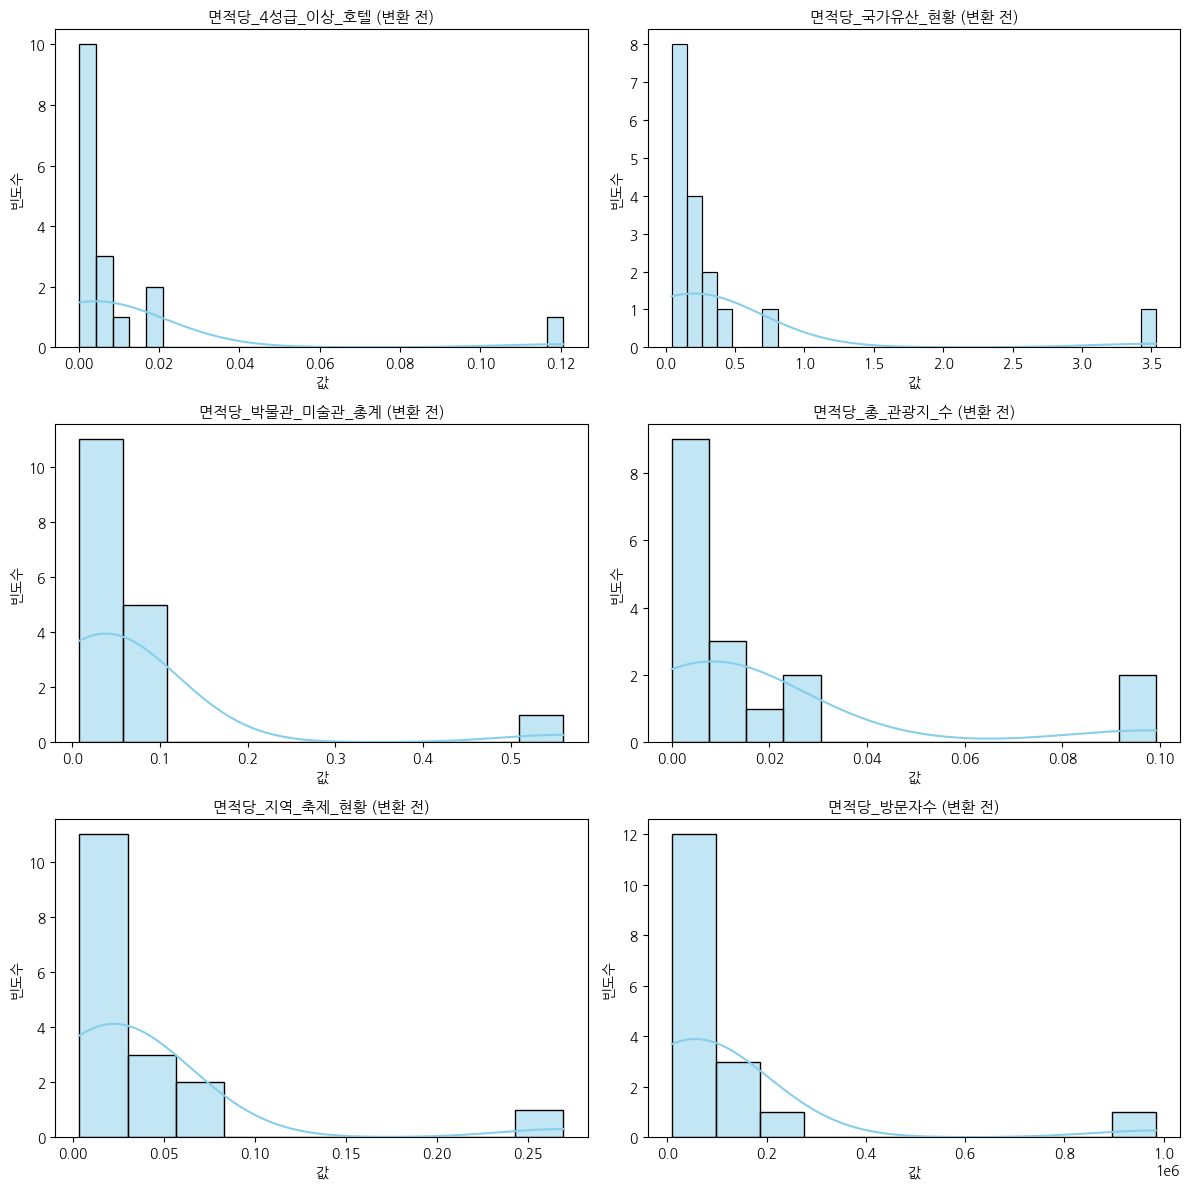

In [26]:
import seaborn as sns
import math

target_columns = ['면적당_4성급_이상_호텔', '면적당_국가유산_현황', '면적당_박물관_미술관_총계', '면적당_총_관광지_수', '면적당_지역_축제_현황', '면적당_방문자수']

n_cols = 2  # 한 줄에 그릴 그래프 개수 (2개씩 나란히)
n_rows = math.ceil(len(target_columns) / n_cols)  # 필요한 행 수 자동 계산

# 변수 개수에 따라 세로 크기(figsize의 뒤쪽 숫자)가 자동으로 늘어납니다.
plt.figure(figsize=(12, 4 * n_rows))

for i, col in enumerate(target_columns, 1):
    plt.subplot(n_rows, n_cols, i)  # 동적으로 바뀐 행/열 수 적용
    sns.histplot(new_df[col], kde=True, color='skyblue')
    plt.title(f'{col} (변환 전)', fontsize=11)
    plt.xlabel('값')
    plt.ylabel('빈도수')

plt.tight_layout()
plt.show()

그래프를 본 결과 치우침이 매우 심함  
→ 로그 변환($\log$) : 큰 값은 엄청나게 축소시키고, 작은 값들은 듬성듬성하게 늘려주는 효과  
따라서 로그 변환을 적용한 뒤 다시 히스토그램을 그리면, 지금처럼 한쪽으로 치우친 모양이 아니라 가운데가 볼록하고 좌우가 완만한 '종 모양(정규분포)'에 가깝게 변하는지 확인!!


--- [시각화] 로그 변환 후 분포 확인 ---


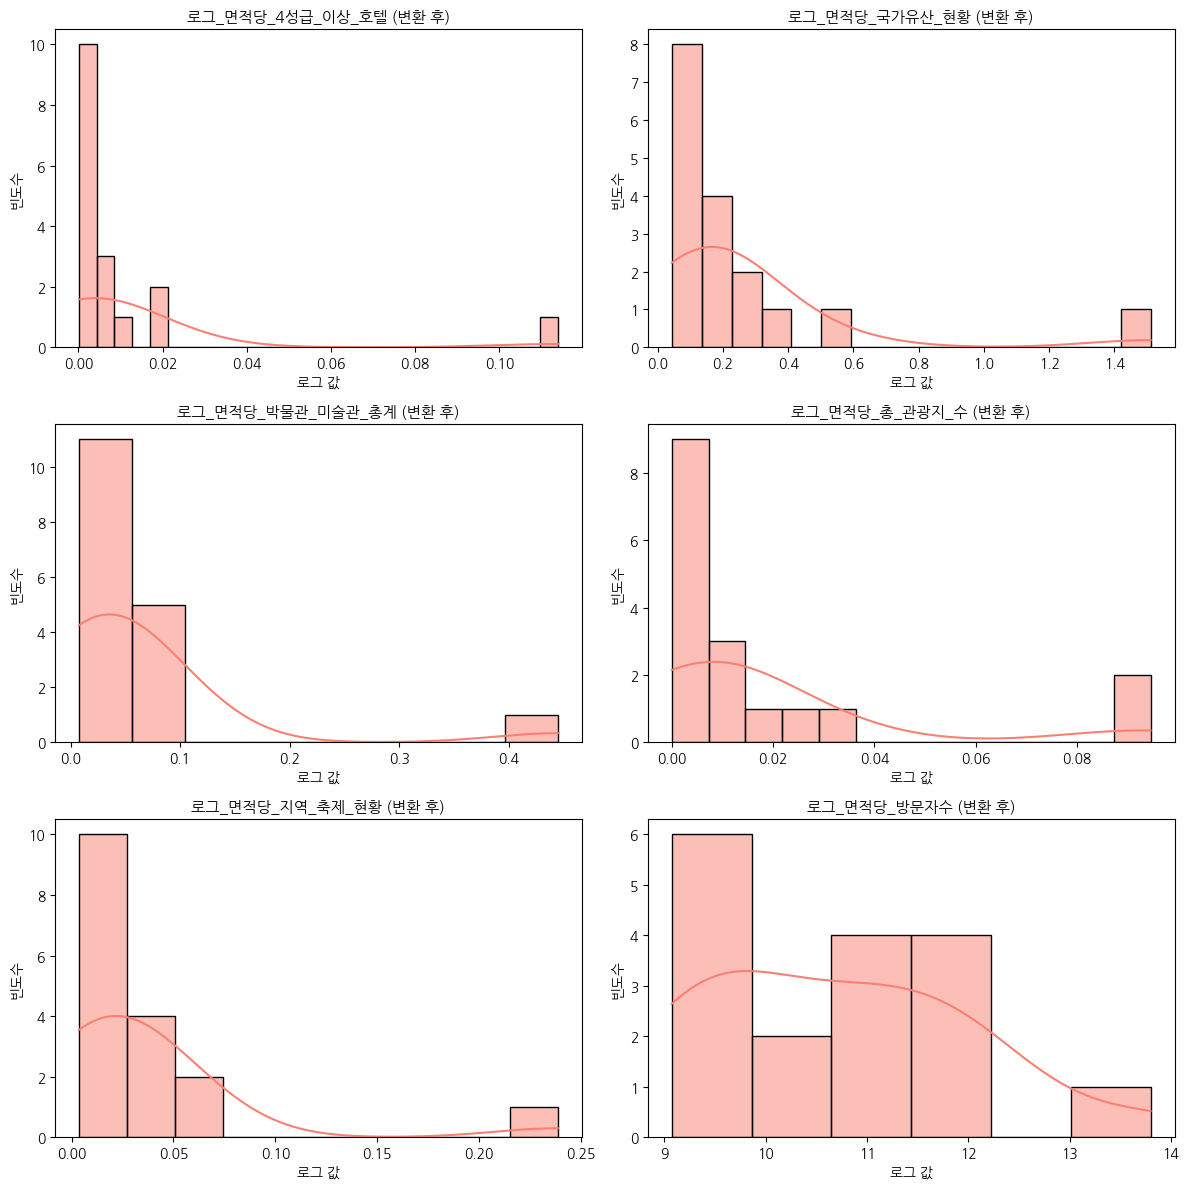

In [27]:
# --- 로그 변환 적용 ---
for col in target_columns:
    new_df[f'로그_{col}'] = np.log1p(new_df[col])


# --- 로그 변환 후 분포 자동 배치 ---
print("\n--- [시각화] 로그 변환 후 분포 확인 ---")
log_columns = [f'로그_{col}' for col in target_columns]

plt.figure(figsize=(12, 4 * n_rows))

for i, col in enumerate(log_columns, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(new_df[col], kde=True, color='salmon')
    plt.title(f'{col} (변환 후)', fontsize=11)
    plt.xlabel('로그 값')
    plt.ylabel('빈도수')

plt.tight_layout()
plt.show()

# 로그변환 대신 순위기반

In [28]:
new_df.head()

,시도명,국립공원_현황,대중교통_만족도_평균,미세먼지_연평균_농도,녹지환경_만족도,면적당_4성급_이상_호텔,면적당_국가유산_현황,면적당_박물관_미술관_총계,면적당_총_관광지_수,면적당_지역_축제_현황,면적당_방문자수,로그_면적당_4성급_이상_호텔,로그_면적당_국가유산_현황,로그_면적당_박물관_미술관_총계,로그_면적당_총_관광지_수,로그_면적당_지역_축제_현황,로그_면적당_방문자수
0,서울특별시,1,4.692857,17.416667,55.6,0.120618,3.530982,0.560132,0.099138,0.269326,984413.289355,0.113881,1.510939,0.444771,0.094527,0.238486,13.799802
1,부산광역시,0,4.667143,13.916667,57.7,0.020743,0.738980,0.103717,0.095938,0.070009,194779.674396,0.020531,0.553299,0.098683,0.091610,0.067667,12.179629
2,대구광역시,1,4.660952,14.166667,48.7,0.004668,0.224076,0.040014,0.009336,0.045349,70258.801149,0.004657,0.202186,0.039234,0.009293,0.044351,11.159955
3,인천광역시,0,4.680476,18.750000,47.8,0.010285,0.268347,0.062645,0.012155,0.044880,165794.811844,0.010233,0.237714,0.060761,0.012082,0.043902,12.018512
4,광주광역시,1,4.643810,13.833333,50.4,0.005989,0.329372,0.099810,0.029943,0.057890,132459.178647,0.005971,0.284707,0.095137,0.029503,0.056276,11.794037


In [29]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# --- 면적 정규화 후 극단치 문제가 있던 5개 변수 → 로그 대신 순위(백분위)로 변환 ---
rank_target_columns = [
    '면적당_4성급_이상_호텔',
    '면적당_국가유산_현황',
    '면적당_박물관_미술관_총계',
    '면적당_총_관광지_수',
    '면적당_지역_축제_현황'
]

for col in rank_target_columns:
    new_df[f'순위_{col}'] = new_df[col].rank(pct=True)  # 0~1 사이 백분위 순위, 동률은 평균 처리

# --- 면적으로 나누지 않은 나머지 변수는 원래 값 그대로 ---
raw_columns = [
    '국립공원_현황',
    '대중교통_만족도_평균',
    '미세먼지_연평균_농도',
    '녹지환경_만족도'
]

# --- 3. 최종 독립변수 (순위변환 5개 + 원본 4개) 합치기 ---
feature_columns = [f'순위_{col}' for col in rank_target_columns] + raw_columns
X = new_df[feature_columns]

# --- 4. 전처리 방식이 다른 변수들을 한 데이블 모았으니, 여기서 한 번에 표준화 ---
scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=feature_columns,
    index=X.index
)

print(X_scaled.describe().T[['mean', 'std', 'min', 'max']])

                           mean       std       min       max
순위_면적당_4성급_이상_호텔  -3.787820e-16  1.030776 -1.632993  1.632993
순위_면적당_국가유산_현황    -3.657205e-16  1.030776 -1.632993  1.632993
순위_면적당_박물관_미술관_총계 -2.612289e-17  1.030776 -1.632993  1.632993
순위_면적당_총_관광지_수    -3.853127e-16  1.030776 -1.632993  1.632993
순위_면적당_지역_축제_현황   -3.918434e-17  1.030776 -1.632993  1.632993
국립공원_현황            1.044916e-16  1.030776 -0.965035  2.582121
대중교통_만족도_평균        6.530724e-17  1.030776 -1.738887  2.063630
미세먼지_연평균_농도       -5.942959e-16  1.030776 -1.440286  1.951391
녹지환경_만족도           1.564108e-15  1.030776 -1.478244  1.753747


- mean (평균): 값이 전부 -3.78e-16, 1.56e-15 등 통계학이나 파이썬에서 e-16은 $10^{-16}$을 의미(사실상 거의 완벽한 0) => 표준화가 되어 모든 변수의 평균이 0으로 맞춰졌음을 의미
- std (표준편차): 모든 변수의 std가 1.030776으로 완전히 동일하게 일치, 모든 변수의 퍼짐 정도(체급)가 똑같아졌다는 뜻입니다. (원래 1.000이 되어야 하지만 샘플 수 $N=17$의 특성상 약간의 보정이 들어간 수치)
---

- 위쪽 5개 순위 변수들의 min은 전부 -1.632993이고, max도 전부 1.632993으로 완벽하게 같음 (원래 원본 데이터에서는 서울 혼자 호텔 수나 관광지 수가 압도적으로 많아서 다른 지역과 수백 배 차이가 났을 텐데, 순위(Rank)로 먼저 펴준 덕분에 극단치가 완전히 사라지고 17개 지역이 완벽하게 대칭을 이루는 예쁜 데이터로 변환되었다는 증거)
- '국립공원_현황'이나 '대중교통_만족도_평균' 같은 변수들을 보면 min, max 범위가 대략 -1.7 ~ +2.5 사이로, 위쪽 순위 변수들의 범위(-1.6 ~ +1.6)와 체급이 거의 비슷(모든 독립변수가 평균 0, 표준편차 1, 데이터 범위 -1.7 ~ +2.5 사이라는 동일한 링 위에 올라오게됨)

In [30]:
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import LeaveOneOut, cross_val_predict

'''
LOOCV는 16개로 학습하고 딱 1개 지역으로 검증하는 과정을 17번 반복하기 때문에,
주어진 적은 데이터를 단 하나도 낭비하지 않고 가장 엄밀하게 모델의 진짜 예측 성능을 평가할 수 있는 최고의 선택
'''

y = new_df['로그_면적당_방문자수']  # 종속변수는 기존에 만들어둔 컬럼 그대로 사용

loo = LeaveOneOut()
alphas = np.logspace(-3, 3, 50)
ridge = RidgeCV(alphas=alphas)

y_pred = cross_val_predict(ridge, X_scaled, y, cv=loo)

residual_df = pd.DataFrame({
    '시도명': new_df['시도명'],
    '실제값': y.values,
    '예측값': y_pred,
    '잔차': y.values - y_pred
}).sort_values('잔차')

print(residual_df)

        시도명        실제값        예측값        잔차
14  제주특별자치도  10.351684  11.772101 -1.420417
10     충청남도   9.906647  10.488921 -0.582274
3     인천광역시  12.018512  12.538810 -0.520298
16  전북특별자치도   9.386495   9.829635 -0.443140
13     경상남도   9.610121   9.980340 -0.370219
11     전라남도   9.235572   9.533903 -0.298331
2     대구광역시  11.159955  11.281042 -0.121087
1     부산광역시  12.179629  12.225211 -0.045582
9      충청북도   9.650373   9.687748 -0.037376
8       경기도  11.023716  10.994248  0.029468
6     울산광역시  10.757532  10.670822  0.086710
15  강원특별자치도   9.072494   8.963285  0.109209
4     광주광역시  11.794037  11.610783  0.183254
12     경상북도   9.179093   8.961576  0.217516
5     대전광역시  11.962805  11.511590  0.451215
7   세종특별자치시  11.004485   9.808600  1.195884
0     서울특별시  13.799802  12.352056  1.447746


# 성능 비교

In [34]:
# 성능 비교
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.model_selection import LeaveOneOut, cross_val_score

# 독립변수(X_scaled)와 종속변수(y)
X_ols = sm.add_constant(X_scaled) # OLS 회귀분석을 위해 X에 상수항 추가

# 성능 비교를 위한 LOOCV 객체 정의
loo = LeaveOneOut()

# ----------------------------------------------------
# [비교 1] 기본 OLS (LinearRegression) LOOCV 성능
ols_sk = LinearRegression()
ols_mse_scores = cross_val_score(ols_sk, X_scaled, y, cv=loo, scoring='neg_mean_squared_error')
# scoring이 neg_...이므로 양수로 바꾸기 위해 -를 붙입니다.
ols_loocv_mse = -ols_mse_scores.mean()

print(f"--- [성능비교] OLS 모델 LOOCV 평균 MSE: {ols_loocv_mse:.4f} ---")

# [비교 2] 규제 모델 (RidgeCV) LOOCV 성능 (이미 수행한 결과 활용)
alphas = np.logspace(-3, 3, 50)
ridge_sk = RidgeCV(alphas=alphas)
ridge_mse_scores = cross_val_score(ridge_sk, X_scaled, y, cv=loo, scoring='neg_mean_squared_error')
ridge_loocv_mse = -ridge_mse_scores.mean()

print(f"--- [성능비교] Ridge 모델 LOOCV 평균 MSE: {ridge_loocv_mse:.4f} ---")
print(f"==> 릿지 모델 도입으로 MSE가 OLS 대비 {((ols_loocv_mse - ridge_loocv_mse) / ols_loocv_mse * 100):.1f}% 개선됨!")


# ----------------------------------------------------
# [추가] OLS 상세 통계 리포트 확인 (statsmodels 활용)
ols_sm_model = sm.OLS(y, X_ols)
ols_results = ols_sm_model.fit()

print("\n--- OLS 상세 통계 분석 리포트 (statsmodels) ---")
ols_results.summary()

--- [성능비교] OLS 모델 LOOCV 평균 MSE: 0.6603 ---
--- [성능비교] Ridge 모델 LOOCV 평균 MSE: 0.4058 ---
==> 릿지 모델 도입으로 MSE가 OLS 대비 38.5% 개선됨!

--- OLS 상세 통계 분석 리포트 (statsmodels) ---


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            로그_면적당_방문자수   R-squared:                       0.941
Model:                            OLS   Adj. R-squared:                  0.865
Method:                 Least Squares   F-statistic:                     12.38
Date:                Wed, 17 Jun 2026   Prob (F-statistic):            0.00159
Time:                        06:42:55   Log-Likelihood:                -4.5076
No. Observations:                  17   AIC:                             29.02
Df Residuals:                       7   BIC:                             37.35
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                10.7114      0.119     89.841      0.000      10.429      10.993
순위_면적당_4성급_이상_호텔      0.3658      0.319      1.148      0.289      -0.388       1.119
순위_면적당_국가유산_현황        0.3015      0.258      1.170      0.280      -0.308       0.911
순위_면적당_박물관_미술관_총계     0.4111      0.403      1.019      0.342      -0.542       1.365
순위_면적당_총_관광지_수        0.2269      0.283      0.801      0.450      -0.443       0.897
순위_면적당_지역_축제_현황      -0.0517      0.494     -0.105      0.920      -1.220       1.116
국립공원_현황              -0.0509      0.307     -0.166      0.873      -0.776       0.674
대중교통_만족도_평균           0.0761      0.313      0.243      0.815      -0.664       0.816
미세먼지_연평균_농도           0.4184      0.218      1.917      0.097      -0.098       0.934
녹지환경_만족도              0.1266      0.227      0.557      0.595      -0.411       0.664
==============================================================================
Omnibus:                        2.003   Durbin-Watson:                   2.264
Prob(Omnibus):                  0.367   Jarque-Bera (JB):                1.544
Skew:                          -0.693   Prob(JB):                        0.462
Kurtosis:                       2.492   Cond. No.                         11.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

데이터가 너무 적어 대부분의 변수가 $P>|t|$ (p-value) 값이 0.462   
이는 **통계적으로 유의미한 변수를 찾기가 어려워 OLS 결과의 신뢰도가 낮다**는 근거   
**예측 위주의 릿지 모델과 LOOCV로 전환했다**

/tmp/ipykernel_7960/2332002623.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=residual_df_sorted, x='잔차', y='시도명', palette=colors, ax=ax)


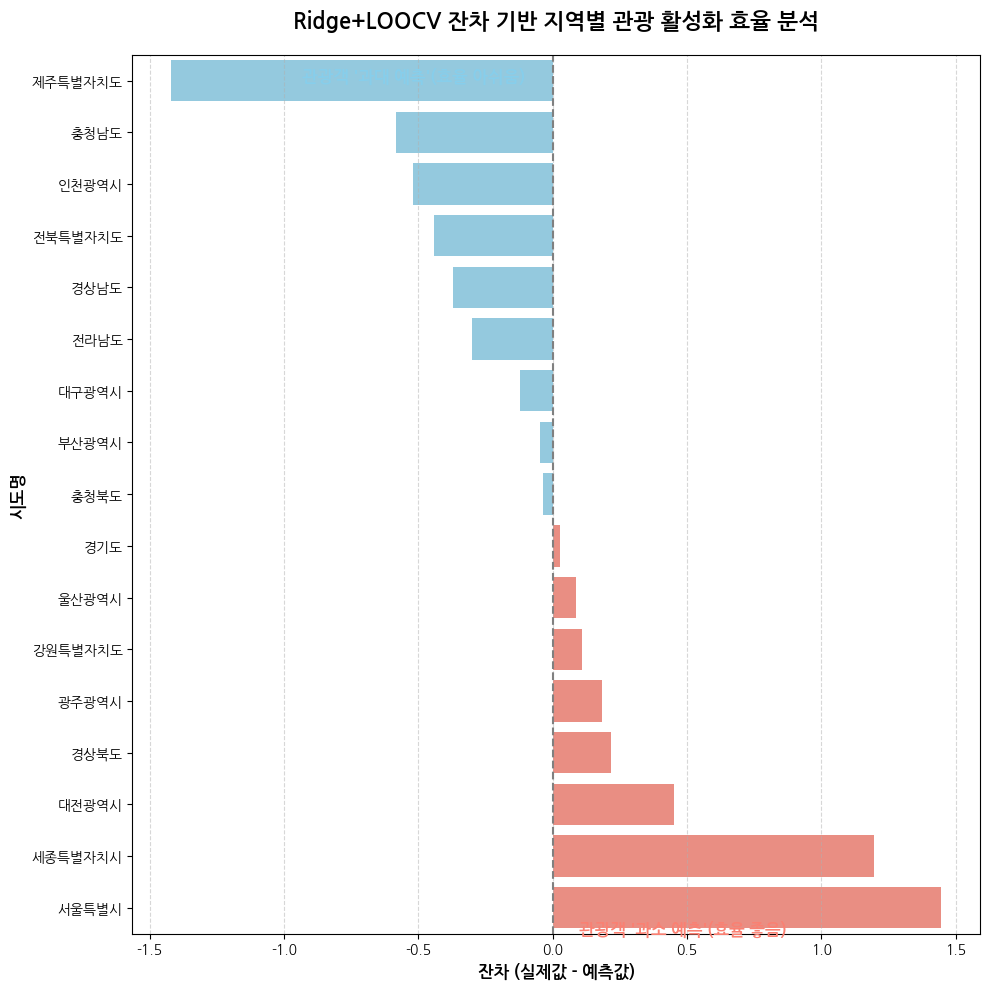

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# 시각화 데이터 준비
# 잔차 순서대로 정렬되어 있는 상태 그대로 사용
residual_df_sorted = residual_df.copy()

# 캔버스 설정
fig, ax = plt.subplots(figsize=(10, 10))

# 잔차 막대 그래프
# 잔차가 양수(과소 예측)인 지역과 음수(과대 예측)인 지역의 색을 다르게 지정
colors = ['salmon' if r >= 0 else 'skyblue' for r in residual_df_sorted['잔차']]
sns.barplot(data=residual_df_sorted, x='잔차', y='시도명', palette=colors, ax=ax)

# 가이드라인 및 텍스트 추가 (인사이트 강조)
ax.axvline(x=0, color='grey', linestyle='--', linewidth=1.5) # 잔차가 0인 중앙선

# 인사이트 라벨링
ax.text(0.1, len(residual_df_sorted)-0.5, "관광객 '과소 예측'(효율 좋음)", fontsize=12, color='salmon', fontweight='bold', ha='left')
ax.text(-0.1, 0, "관광객 '과대 예측'(효율 아쉬움)", fontsize=12, color='skyblue', fontweight='bold', ha='right')

# 세부 스타일 설정
ax.set_title('Ridge+LOOCV 잔차 기반 지역별 관광 활성화 효율 분석', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('잔차 (실제값 - 예측값)', fontsize=12, fontweight='bold')
ax.set_ylabel('시도명', fontsize=12, fontweight='bold')
ax.grid(axis='x', linestyle='--', alpha=0.5) # x축 눈금 가이드라인

plt.tight_layout()
plt.show()